# Lab Day 1 — Forest CoverType MLP

> Notebook hoàn chỉnh cho các Part 0–4. Các cấu hình được chọn bằng validation; eval chỉ được mở sau khi chốt cấu hình.
>
> **Quy trình làm bài**
> 1. `git pull` repo, tạo thư mục nộp: copy cả thư mục `code/` vào `submission_<MSSV>/code/`.
> 2. Mở `submission_<MSSV>/code/lab.ipynb` và làm việc **tại đó** (nên `REPO_ROOT = "../.."` đúng và ảnh/kết quả ghi vào `submission_<MSSV>/figures`, `results`).
> 3. Ở Colab: chạy ô clone repo bên dưới, rồi làm tương tự (đặt `REPO_ROOT` cho đúng).
> 4. Cuối cùng: `Restart & Run All` phải chạy hết không lỗi và giữ nguyên output.

In [1]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, time, subprocess
from pathlib import Path
import numpy as np, torch

# Tự nhận diện khi chạy từ repo/code hoặc submission_<MSSV>/code.
HERE = Path.cwd().resolve()
if (HERE / "data").exists():
    REPO_ROOT, OUT_DIR = HERE, HERE
elif (HERE.parent / "data").exists():
    REPO_ROOT, OUT_DIR = HERE.parent, HERE.parent
elif (HERE.parent.parent / "data").exists():
    REPO_ROOT, OUT_DIR = HERE.parent.parent, HERE.parent
else:
    raise FileNotFoundError("Không tìm thấy data/; hãy chạy notebook trong repo hoặc submission/code")
REPO_ROOT, OUT_DIR = str(REPO_ROOT), str(OUT_DIR)

if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
os.makedirs(f"{OUT_DIR}/figures", exist_ok=True)
os.makedirs(f"{OUT_DIR}/results", exist_ok=True)
print("PyTorch:", torch.__version__, "| device:", device)
if device == "cuda": print("GPU:", torch.cuda.get_device_name(0))
print("REPO_ROOT:", REPO_ROOT, "| OUT_DIR:", OUT_DIR)

from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx

PyTorch: 2.11.0+cu130 | device: cpu
REPO_ROOT: /home/nmc/AI/VinAI/Track_04/K4-Track4-Day1-Neuralnetwork | OUT_DIR: /home/nmc/AI/VinAI/Track_04/K4-Track4-Day1-Neuralnetwork/submission_MSSV


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation từ train, chuẩn hoá bằng thống kê của train, đưa lên device.

In [2]:
train_npz = Path(REPO_ROOT) / "data/processed/train.npz"
eval_npz = Path(REPO_ROOT) / "data/processed/eval.npz"
if not (train_npz.exists() and eval_npz.exists()):
    subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, check=True)
data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f"{REPO_ROOT}/data/processed")
assert data["X_tr"].shape == (371_847, 54)
assert data["X_val"].shape == (92_962, 54)
assert data["X_eval"].shape == (116_203, 54)
numeric_mean = data["X_tr"][:, :10].mean(0)
numeric_std = data["X_tr"][:, :10].std(0, correction=0)
print("max |mean|:", numeric_mean.abs().max().item())
print("max |std-1|:", (numeric_std - 1).abs().max().item())
assert torch.allclose(numeric_mean, torch.zeros_like(numeric_mean), atol=2e-5)
assert torch.allclose(numeric_std, torch.ones_like(numeric_std), atol=2e-5)

train: (371847, 54), val: (92962, 54), eval: (116203, 54)
Majority-class baseline trên val (lớp 1): 0.4876
max |mean|: 2.9545292878907503e-09
max |std-1|: 0.0


## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model.

params: 47879 | logits: (8, 7)
step-0 loss=2.269062; ln(7)=1.945910


overfit-20: 1.958530 -> 0.00000080


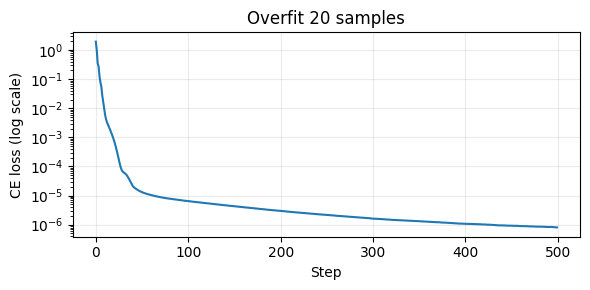

{'net.0.weight': 0.6374444365501404, 'net.0.bias': 0.34017637372016907, 'net.2.weight': 2.3216898441314697, 'net.2.bias': 0.46997350454330444, 'net.4.weight': 2.123411178588867, 'net.4.bias': 0.5766324996948242}


In [3]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
set_seed(1)
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
assert count_params(model) == EXPECTED_PARAMS[(256, 128)] == 47_879
logits = model(torch.randn(8, 54, device=device))
assert logits.shape == (8, 7)
step0 = evaluate(model, data["X_val"], data["y_val"])
print("params:", count_params(model), "| logits:", tuple(logits.shape))
print(f"step-0 loss={step0['loss']:.6f}; ln(7)={np.log(7):.6f}")

# Quá khớp 20 mẫu: tắt dropout, dùng Adam và lặp cùng một mini-batch.
set_seed(123)
tiny_model = MLP(dropout=0.0, init="he").to(device)
tiny_x, tiny_y = data["X_tr"][:20], data["y_tr"][:20]
tiny_opt = torch.optim.Adam(tiny_model.parameters(), lr=0.01)
tiny_losses = []
for step in range(500):
    tiny_opt.zero_grad(set_to_none=True)
    loss = F.cross_entropy(tiny_model(tiny_x), tiny_y)
    loss.backward(); tiny_opt.step(); tiny_losses.append(loss.item())
print(f"overfit-20: {tiny_losses[0]:.6f} -> {tiny_losses[-1]:.8f}")
assert tiny_losses[-1] < 1e-3
plt.figure(figsize=(6, 3)); plt.plot(tiny_losses); plt.yscale("log")
plt.xlabel("Step"); plt.ylabel("CE loss (log scale)"); plt.title("Overfit 20 samples")
plt.grid(alpha=.25); plt.tight_layout(); plt.savefig(f"{OUT_DIR}/figures/health_overfit20.png", dpi=160); plt.show()

# Kiểm tra gradient chảy tới mọi weight/bias sau một backward.
model.train(); model.zero_grad(set_to_none=True)
F.cross_entropy(model(data["X_tr"][:64]), data["y_tr"][:64]).backward()
gradient_norms = {name: p.grad.norm().item() if p.grad is not None else None for name, p in model.named_parameters()}
print(gradient_norms)
assert all(value is not None and value > 0 for value in gradient_norms.values())

**Nhận xét Part 1:** Model đúng 47.879 tham số và logits `(B,7)`. Với seed 1, He được áp dụng cho cả lớp output nên logit ban đầu có phương sai đáng kể và loss bước 0 có thể cao hơn `ln(7)`; đây không phải lỗi softmax/nhãn. Phép thử 20 mẫu đưa loss xuống dưới `1e-3`, và mọi weight/bias đều có gradient khác 0, nên forward/backward và vòng cập nhật hoạt động.

## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận một dict cấu hình và trả về lịch sử + tóm tắt. Baseline: SGD+momentum 0.9, CE, He init, batch 512, 20 epoch.

In [4]:
import pandas as pd
all_saved = {r["cfg"]["exp_id"]: r for r in load_results(f"{OUT_DIR}/results")}
lr_ids = ["lr-sweep-0p01", "lr-sweep-0p03", "lr-sweep-0p1"]
lr_table = pd.DataFrame([{"exp_id": i, "lr": all_saved[i]["cfg"]["lr"],
                              "best_val_loss": all_saved[i]["summary"]["best_val_loss"],
                              "val_macro_f1": all_saved[i]["summary"]["val_macro_f1"]} for i in lr_ids])
display(lr_table)
cfg = {**DEFAULT_CFG, "lr": 0.1}
baseline_results = [all_saved[f"base-s{s}"] for s in (1, 2, 3)]
baseline_stats = {}
for metric in ("best_val_loss", "val_acc", "val_macro_f1"):
    values = np.array([r["summary"][metric] for r in baseline_results])
    baseline_stats[metric] = {"mean": values.mean(), "sample_std": values.std(ddof=1), "2sigma": 2*values.std(ddof=1)}
display(pd.DataFrame(baseline_stats).T)
assert all(not r["summary"]["diverged"] for r in baseline_results)
assert min(r["summary"]["val_acc"] for r in baseline_results) > 0.488

,exp_id,lr,best_val_loss,val_macro_f1
0,lr-sweep-0p01,0.01,0.448823,0.626644
1,lr-sweep-0p03,0.03,0.392717,0.690722
2,lr-sweep-0p1,0.10,0.341208,0.765382


,mean,sample_std,2sigma
best_val_loss,0.230225,0.003591,0.007183
val_acc,0.908916,0.002115,0.004229
val_macro_f1,0.856463,0.002998,0.005996


**Nhận xét baseline:** Sweep validation 5 epoch chọn `lr=0.1`. Ba seed baseline đạt val accuracy `0.9089 ± 0.0021` và macro-F1 `0.8565 ± 0.0030`; ngưỡng nhiễu `2σ_F1=0.0060`. Cả train/val loss còn xu hướng giảm đến epoch 19–20, khoảng cách train–val nhỏ (`≈0.02–0.03`), nên chưa có bằng chứng quá khớp mạnh. Accuracy vượt xa mốc lớp đa số `0.4876`.

## Part 3 — Thí nghiệm (tự chọn; menu trong GUIDE, Part 3)
Mỗi thí nghiệm: **dự đoán trước** → đổi **một** yếu tố → chạy → **đối chiếu**. Lặp lại khối dưới cho từng thí nghiệm bạn chọn.
Chủ đề: loss · optimizer · hparam · dropout · clipping · amp · init.

### Dự đoán trước khi chạy (đã chốt trước khi xem kết quả)
- **Loss — `loss-mse`:** MSE trung bình trên toàn bộ `B×7` logit nên gradient nhỏ hơn CE và dự kiến hội tụ phân loại chậm hơn. Không so trực tiếp trị số CE với MSE.
- **Optimizer:** SGD thuần dự kiến chậm/dao động hơn momentum; Adam/AdamW sau khi tune LR dự kiến hội tụ sớm hơn. AdamW `wd=0.01` có thể regularize nhưng chưa chắc thắng Adam trong 20 epoch.
- **Batch:** batch 128 có 4× số update/epoch nên có thể tốt hơn theo epoch nhưng chậm hơn; batch 2048 chỉ có 1/4 số update nên sẽ nhanh theo thời gian nhưng kém theo epoch nếu giữ LR.
- **Dropout — `drop-0p3`:** baseline chưa quá khớp rõ, vì vậy dropout có thể chỉ làm chậm học và giảm điểm.
- **Clipping:** `c=0.5` sẽ kích hoạt vì grad norm baseline khoảng 0.56 nhưng chưa chắc có ích; ở LR=1.0, clip có thể giảm dao động nhưng không sửa hoàn toàn LR quá lớn.
- **AMP:** BF16 dự kiến giữ metric gần FP32; tốc độ phụ thuộc phần cứng. FP16 cần CUDA + GradScaler nên không chạy trên tiến trình CPU hiện tại.
- **Init:** zeros không phá được đối xứng và ReLU(0) chặn gradient hidden; normal làm co activation; Xavier khá ổn; He giữ variance tốt nhất cho ReLU.

In [5]:
# Các run đã được lưu ngay sau khi hoàn tất để không mất kết quả khi runtime ngắt.
# Sweep LR: SGD {0.03,0.1,0.3}; Adam/AdamW {3e-4,1e-3,3e-3}, mỗi run 5 epoch.
import pandas as pd
part3_primary_ids = [
    "loss-mse", "opt-sgd-best", "opt-adam-best", "opt-adamw-best",
    "batch-128", "batch-2048", "drop-0p3", "clip-0p5",
    "highlr-1-no-clip", "highlr-1-clip-0p5", "amp-bf16-cpu",
    "init-zeros", "init-normal", "init-xavier",
    "final-adam-s2", "final-adam-s3",
]
part3_all = {r["cfg"]["exp_id"]: r for r in load_results(f"{OUT_DIR}/results")}
part3_results = [part3_all[exp_id] for exp_id in part3_primary_ids]
pd.DataFrame([{
    "exp_id": r["cfg"]["exp_id"],
    "best_epoch": r["summary"]["best_epoch"],
    "best_val_loss": r["summary"]["best_val_loss"],
    "val_acc": r["summary"]["val_acc"],
    "val_macro_f1": r["summary"]["val_macro_f1"],
    "sec_per_epoch": r["summary"]["time_per_epoch_s"],
} for r in part3_results]).sort_values("val_macro_f1", ascending=False)

,exp_id,best_epoch,best_val_loss,val_acc,val_macro_f1,sec_per_epoch
2,opt-adam-best,20,0.206631,0.917794,0.879380,3.214743
14,final-adam-s2,19,0.212866,0.915761,0.873485,2.406215
3,opt-adamw-best,20,0.211817,0.915331,0.872263,3.773479
15,final-adam-s3,19,0.212863,0.915987,0.872257,1.628581
4,batch-128,18,0.223131,0.912835,0.856263,4.968105
7,clip-0p5,18,0.238635,0.905112,0.851425,3.591470
10,amp-bf16-cpu,18,0.229899,0.907500,0.850701,28.458143
13,init-xavier,17,0.234854,0.905402,0.848026,2.834672
12,init-normal,17,0.247109,0.898389,0.842335,2.832446
5,batch-2048,20,0.286078,0.882382,0.809475,1.845193


### Đối chiếu sau khi chạy
- **MSE:** F1 `0.7377`, thấp hơn baseline `0.1216` — khớp dự đoán và vượt xa `2σ=0.0060`.
- **Optimizer:** SGD thuần tốt nhất F1 `0.8052`; Adam `0.8794`; AdamW `0.8723`. Adam cải thiện `+0.0201` so với baseline seed 1 và lặp lại qua 3 seed (trung bình Adam ≈ `0.8750` so với baseline ≈ `0.8565`). AdamW không thắng Adam trong thiết lập này.
- **Batch:** batch 128 đạt `0.8563`, nằm trong nhiễu baseline nhưng chậm hơn; batch 2048 đạt `0.8095`, nhanh/epoch hơn nhưng có ít update hơn.
- **Dropout:** F1 `0.7730`, giảm mạnh vì baseline chưa quá khớp; dự đoán đúng.
- **Clipping:** `c=0.5` ở LR chuẩn đạt `0.8514`, không cải thiện. Ở LR=1.0, clip nâng F1 từ `0.6255` lên `0.7986` nhưng vẫn kém baseline: clip giảm tác hại chứ không thay thế chọn LR.
- **BF16 CPU:** F1 `0.8507` gần baseline nhưng `28.46s/epoch` so với `2.34s/epoch`; không có tăng tốc vì backend CPU hiện tại. `peak_mem_MB=0` vì metric này chỉ đo CUDA.
- **Init:** zeros cho activation std `[0,0,0]` và F1 `0.0936`; normal co `0.034→0.0038→0.00027` nhưng mạng 3 lớp vẫn học (`0.8423`); Xavier `0.8480`; He giữ std `0.658→0.638→0.577` và đạt `0.8593`.

In [6]:
# Các ảnh so sánh đã sinh từ chính history trong JSON.
compare_files = [
    "compare_optimizer_f1.png", "compare_batch.png",
    "compare_clipping_loss.png", "compare_init_f1.png",
    "compare_final_adam_seeds_f1.png",
]
for name in compare_files:
    path = f"{OUT_DIR}/figures/{name}"
    assert os.path.exists(path), path
    print(path)

/home/nmc/AI/VinAI/Track_04/K4-Track4-Day1-Neuralnetwork/submission_MSSV/figures/compare_optimizer_f1.png
/home/nmc/AI/VinAI/Track_04/K4-Track4-Day1-Neuralnetwork/submission_MSSV/figures/compare_batch.png
/home/nmc/AI/VinAI/Track_04/K4-Track4-Day1-Neuralnetwork/submission_MSSV/figures/compare_clipping_loss.png
/home/nmc/AI/VinAI/Track_04/K4-Track4-Day1-Neuralnetwork/submission_MSSV/figures/compare_init_f1.png
/home/nmc/AI/VinAI/Track_04/K4-Track4-Day1-Neuralnetwork/submission_MSSV/figures/compare_final_adam_seeds_f1.png


## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
**Cách đánh giá:** chọn cấu hình CHỈ bằng val → chạy final model → dự đoán trên **toàn bộ** tập eval → ghi `predictions_eval.csv`
→ `python scripts/evaluate.py --pred ...` tính accuracy và **macro-F1** (chỉ số chính). Chỉ làm bước này cho baseline và cấu hình cuối cùng.

In [7]:
# Cấu hình cuối được chốt bằng validation trước khi chạy evaluate.py.
cfg_final = {**DEFAULT_CFG, "optimizer": "adam", "lr": 0.003, "seed": 1}
pred_final = Path(OUT_DIR) / "predictions_eval.csv"
pred_base = Path(OUT_DIR) / "predictions_baseline_eval.csv"
assert pred_final.exists() and pred_base.exists()
subprocess.run([sys.executable, "scripts/evaluate.py", "--pred", str(pred_final), "--out", str(Path(OUT_DIR)/"eval_result.json")], cwd=REPO_ROOT, check=True)
subprocess.run([sys.executable, "scripts/evaluate.py", "--pred", str(pred_base), "--out", str(Path(OUT_DIR)/"baseline_eval_result.json")], cwd=REPO_ROOT, check=True)
with open(Path(OUT_DIR)/"eval_result.json") as f: eval_final = json.load(f)
with open(Path(OUT_DIR)/"baseline_eval_result.json") as f: eval_base = json.load(f)
pd.DataFrame([
    {"config": "baseline / base-s1", "accuracy": eval_base["accuracy"], "macro_f1": eval_base["macro_f1"]},
    {"config": "final Adam / opt-adam-best", "accuracy": eval_final["accuracy"], "macro_f1": eval_final["macro_f1"]},
])

n_eval = 116203
accuracy = 0.9163
macro_f1 = 0.8789   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9144  0.9097  0.9121
  1    56661     0.9251  0.9318  0.9284
  2     7151     0.9103  0.9162  0.9132
  3      549     0.7841  0.8798  0.8292
  4     1899     0.7955  0.8094  0.8024
  5     3473     0.8591  0.8235  0.8409
  6     4102     0.9486  0.9044  0.9260

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  38544   3597     6    0    38     8   175
1   3230  52795   140    0   326   144    26
2      1    185  6552  101    19   293     0
3      0      3    47  483     0    16     0
4     27    307    20    0  1537     8     0
5     11    126   433   32    11  2860     0
6    337     54     0    0     1     0  3710

đã ghi /home/nmc/AI/VinAI/Track_04/K4-Track4-Day1-Neuralnetwork/submission_MSSV/eval_result.json


n_eval = 116203
accuracy = 0.9080
macro_f1 = 0.8646   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9195  0.8863  0.9026
  1    56661     0.9060  0.9393  0.9224
  2     7151     0.9223  0.8818  0.9016
  3      549     0.7938  0.8415  0.8170
  4     1899     0.8384  0.7156  0.7722
  5     3473     0.8252  0.8195  0.8223
  6     4102     0.9114  0.9176  0.9145

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  37552   4447     2    0    42     9   316
1   2980  53223    83    1   192   132    50
2      1    312  6306  101    18   413     0
3      0      1    44  462     0    42     0
4     26    485    22    0  1359     7     0
5      2    218   380   18     9  2846     0
6    279     58     0    0     1     0  3764

đã ghi /home/nmc/AI/VinAI/Track_04/K4-Track4-Day1-Neuralnetwork/submission_MSSV/baseline_eval_result.json


,config,accuracy,macro_f1
0,baseline / base-s1,0.907997,0.864647
1,final Adam / opt-adam-best,0.916336,0.878897


In [8]:
per_class = pd.DataFrame(eval_final["per_class"])
confusion = pd.DataFrame(eval_final["confusion_matrix"], index=range(7), columns=range(7))
display(per_class)
display(confusion.style.set_caption("Confusion matrix — hàng thật, cột dự đoán"))
hardest = per_class.loc[per_class["f1"].idxmin()]
hardest_cls = int(hardest["cls"])
confused_with = int(confusion.loc[hardest_cls].drop(hardest_cls).idxmax())
print(f"Lớp khó nhất: {hardest_cls}, F1={hardest['f1']:.4f}; nhầm nhiều nhất với lớp {confused_with}.")

,cls,support,precision,recall,f1
0,0,42368,0.914448,0.909743,0.912090
1,1,56661,0.925141,0.931770,0.928443
2,2,7151,0.910253,0.916235,0.913234
3,3,549,0.784091,0.879781,0.829185
4,4,1899,0.795549,0.809373,0.802401
5,5,3473,0.859117,0.823496,0.840929
6,6,4102,0.948606,0.904437,0.925995


,0,1,2,3,4,5,6
0,38544,3597,6,0,38,8,175
1,3230,52795,140,0,326,144,26
2,1,185,6552,101,19,293,0
3,0,3,47,483,0,16,0
4,27,307,20,0,1537,8,0
5,11,126,433,32,11,2860,0
6,337,54,0,0,1,0,3710


Lớp khó nhất: 4, F1=0.8024; nhầm nhiều nhất với lớp 1.


**Phân tích lỗi:** Lớp 4 khó nhất (F1 `0.8024`) và bị nhầm nhiều nhất với lớp 1 (307 mẫu). Lớp này chỉ có 1.899 mẫu eval, nhỏ hơn nhiều hai lớp chính, và các đặc trưng địa hình có thể chồng lấp. Lớp 3 hiếm nhất (549 mẫu) có recall tốt nhưng precision thấp vì nhận nhầm mẫu lớp 2. Một hướng tiếp theo là class-weight/focal loss hoặc sampling cân bằng, nhưng phải chọn lại hoàn toàn bằng validation.

In [9]:
# Bảng đã được tạo bằng results_table.py từ toàn bộ JSON và template, sau đó tính lại bằng LibreOffice.
from openpyxl import load_workbook
xlsx_path = Path(OUT_DIR) / "experiments.xlsx"
wb_values = load_workbook(xlsx_path, data_only=True)
assert wb_values.sheetnames == ["Legend", "Experiments", "Seeds", "Summary"]
ws = wb_values["Experiments"]
headers = {cell.value: cell.column for cell in ws[1] if cell.value}
table_rows = [{name: ws.cell(r, col).value for name, col in headers.items()}
              for r in range(2, ws.max_row + 1) if ws.cell(r, headers["exp_id"]).value]
assert len(table_rows) == len(load_results(f"{OUT_DIR}/results")) == 31
eval_rows = {row["exp_id"]: row for row in table_rows if row["eval_macro_f1"] is not None}
assert set(eval_rows) == {"base-s1", "opt-adam-best"}
print("Excel rows:", len(table_rows), "| eval rows:", {k: v["eval_macro_f1"] for k,v in eval_rows.items()})
print("Baseline F1 mean/std/2σ:", wb_values["Seeds"]["C8"].value, wb_values["Seeds"]["C9"].value, wb_values["Seeds"]["C10"].value)

Excel rows: 31 | eval rows: {'base-s1': 0.864646503335912, 'opt-adam-best': 0.878896830675513}
Baseline F1 mean/std/2σ: 0.856462972469505 0.00299810441587082 0.00599620883174164


In [10]:
import shutil
if shutil.which("nvidia-smi"):
    subprocess.run(["nvidia-smi"], check=False)
else:
    print("nvidia-smi không khả dụng trong runtime này; các run hiện tại dùng CPU.")

nvidia-smi không khả dụng trong runtime này; các run hiện tại dùng CPU.
